# The Note's Learning Rules as Transition Matrices

`crossover_transitions.ipynb` compares hand-built transition matrices on a crossover
between two length-3 sequences. This notebook does two further things:

1. Writes the learning rules from the note as transition matrices $T$, one rule at a time.
2. Runs them on longer sequences: 5 patterns with 1 shared pattern, and 5 patterns with a
   shared run of 3.

The coherent rules, eqs. (18) and (19), are set aside. As matrices they are the same
matrices as (16) and (17) at different weights, so the sweeps below reach them by toggling
the weight $w$ rather than listing them separately.

Everything uses `kuramoto_transition.TransitionNetwork` and `kuramoto_library2` as they
stand. No new dynamics, no new kernel.

In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

from collections import Counter

import numpy as np
import scipy.linalg as sla
import matplotlib.pyplot as plt

import kuramoto_library2 as krm
import kuramoto_transition as ktr

In [2]:
# Same configuration as crossover_transitions.ipynb.
CONFIG = dict(
    dt=0.05,
    T=30.0,
    frequency_std=0.3,
    phase_noise=0.01,
    d=3,
    corruption_rate=0.2,
    tolerance=0.8,
    mode="ode",
)

N         = 100
MARGIN    = 0.01
SEED_POOL = 10_000
kinds     = ["correct", "crossed", "incomplete"]

---

# 1. The rules as transition matrices

$T[\alpha,\beta]$ is how strongly pattern $\beta$ drives pattern $\alpha$: row is the
destination, column the source. Each rule in the note says which earlier patterns predict
the next one and with what weight, so each rule is a set of entries in $T$.

Write $\Sigma^{(k)}$ for `ktr.shift_transition(P, nhop=k)`, the matrix whose only entries are
$T[\mu+k,\mu]=1$, and $\Sigma \equiv \Sigma^{(1)}$ for the plain successor chain. Every rule
below is a weighted sum of those.

## One difference from the note

The note's rules multiply overlaps of different patterns, such as $m_\mu|m_{\mu-1}|^2$. The
gate in the transition-matrix dynamics is

$$V_i = \sum_a\sum_\alpha \xi_i^{a,\alpha}\underbrace{\sum_\beta T^a_{\alpha\beta}\bigl(m_i^{a,\beta}\bigr)^d}_{\text{gate}},$$

a weighted sum of $d$-th powers. It cannot form a product of two different overlaps. So the
matrices below are the additive versions: the same patterns vote for the same successor, but
in sum rather than in product.

The difference is that a product is a veto and a sum is not. $m_\mu|m_{\mu-1}|^2$ goes to
zero if either overlap decays. $m_\mu^3 + w\,m_{\mu-1}^3$ keeps driving on the chain term
alone.

## Magnitude-gated bigram rule / one-step context rule — eqs. (15), (16)

$$h^{\text{bigram}}_i = \sum_\mu \xi_i^{\mu+1}\, m_\mu\,|m_{\mu-1}|^2$$

Pattern $\mu+1$ is predicted by $\mu$ and $\mu-1$. Two entries in $T$, and one weight $w$
setting how loudly the older lag speaks:

$$T[\mu{+}1,\mu] = 1,\qquad T[\mu{+}1,\mu{-}1] = w
\qquad\Longrightarrow\qquad T = \Sigma + w\,\Sigma^{(2)}$$

$w$ is the main dial in this notebook. $w=0$ is the plain chain. The coherent bigram (18)
sits at small $w$ and the magnitude-gated bigram at large $w$, so sweeping $w$ covers both.

## Multilag context rule — eq. (17)

$$h^{\text{multilag}}_i = \sum_\mu \xi_i^{\mu+1}\, m_\mu\left(w_0|m_\mu|^2 + w_1|m_{\mu-1}|^2 + w_2|m_{\mu-2}|^2\right)$$

The bigram rule with more lags gating the transition. Three patterns vote, one per lag, and
the note already writes the $w_k$ as separate weights.

$$T[\mu{+}1,\mu{-}k] = w_k \qquad\Longrightarrow\qquad T = \Sigma + w_1\Sigma^{(2)} + w_2\Sigma^{(3)}$$

The coherent trigram (19) has the same three entries at different weights, so it is covered
here too.

## Residual bigram rule — eqs. (20), (21)

$$\bar\xi^{\mu+1} = \frac{1}{|\mathcal{S}(\mu)|}\sum_{\nu\in\mathcal{S}(\mu)}\xi^\nu,
\qquad
h^{\text{res}}_i = \sum_\mu \bar\xi_i^{\mu+1} m_\mu |m_\mu|^2
   + \sum_\mu\bigl(\xi_i^{\mu+1}-\bar\xi_i^{\mu+1}\bigr) m_\mu |m_{\mu-1}|^2$$

An ambiguous mean prediction plus a branch-specific residual.

The mean part needs a readout that crosses branches, which section 2 shows how to write. It
changes little though: at a shared pattern the plain chain already drives both branches'
successors from the same column, with the same overlap. What is left is the residual, which
is one edge from the last unshared pattern before the shared run to the first unshared
pattern after it. For a shared run of length $L$ that edge is $\Sigma^{(L+1)}$:

$$T = \Sigma + w\,\Sigma^{(L+1)}$$

This is the only rule that has to be told where the branch is.

## Summary

| eq. | rule | voters for $\mu+1$ | matrix |
|---|---|---|---|
| — | chain (baseline) | $\mu$ | $\Sigma$ |
| (15), (16) | magnitude-gated bigram | $\mu$, $\mu-1$ | $\Sigma + w\Sigma^{(2)}$ |
| (17) | multilag context | $\mu$, $\mu-1$, $\mu-2$ | $\Sigma + w_1\Sigma^{(2)} + w_2\Sigma^{(3)}$ |
| (20), (21) | residual bigram | $\mu$, plus one branch-specific edge | $\Sigma + w\Sigma^{(L+1)}$ |

On a real-valued state $\overline{m}=m$ and $|m|^2=m^2$, so the conjugates that distinguish
(18) and (19) do nothing here. That is the other reason they are not listed separately.

In [3]:
def lag_matrix(P, weights, boundary=None):
    """Sigma + w_1 Sigma^(2) + w_2 Sigma^(3) + ... , normalized to unit total weight.

    weights[k] is the weight on the lag-k vote, so weights[0] is the plain chain.
    Normalizing keeps the total drive independent of how many lags vote, which is what makes
    the rules comparable to each other and to `chain`."""
    T = sum(w * ktr.shift_transition(P, nhop=k + 1, boundary=boundary)
            for k, w in enumerate(weights) if w)
    return T / sum(w for w in weights if w)


W_VALUES = [0.0, 0.5, 1.0, 2.0, 4.0]     # the lag-2 weight in Sigma + w Sigma^(2)

def note_catalogue(P, shared_run=1):
    """The bigram family at several w, plus multilag and the residual edge.

    w = 0 is the plain chain. `residual bigram` is the only rule that needs the geometry:
    its edge is nhop = L + 1 for a shared run of length L."""
    catalogue = {}
    for w in W_VALUES:
        label = "chain (w=0)" if w == 0 else f"bigram w={w:g}"
        catalogue[label] = lag_matrix(P, [1.0, w])
    catalogue["multilag (.5, .25)"] = lag_matrix(P, [1.0, 0.5, 0.25])
    catalogue["residual bigram"]    = lag_matrix(P, [1.0] + [0.0] * shared_run + [1.0])
    return catalogue


for name, T in note_catalogue(5).items():
    print(f"{name}\n{np.round(T, 3)}\n")

chain (w=0)
[[0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 1.]]

bigram w=0.5
[[0.    0.    0.    0.    0.   ]
 [0.667 0.    0.    0.    0.   ]
 [0.333 0.667 0.    0.    0.   ]
 [0.    0.333 0.667 0.    0.   ]
 [0.    0.    0.333 1.    1.   ]]

bigram w=1
[[0.  0.  0.  0.  0. ]
 [0.5 0.  0.  0.  0. ]
 [0.5 0.5 0.  0.  0. ]
 [0.  0.5 0.5 0.  0. ]
 [0.  0.  0.5 1.  1. ]]

bigram w=2
[[0.    0.    0.    0.    0.   ]
 [0.333 0.    0.    0.    0.   ]
 [0.667 0.333 0.    0.    0.   ]
 [0.    0.667 0.333 0.    0.   ]
 [0.    0.    0.667 1.    1.   ]]

bigram w=4
[[0.  0.  0.  0.  0. ]
 [0.2 0.  0.  0.  0. ]
 [0.8 0.2 0.  0.  0. ]
 [0.  0.8 0.2 0.  0. ]
 [0.  0.  0.8 1.  1. ]]

multilag (.5, .25)
[[0.    0.    0.    0.    0.   ]
 [0.571 0.    0.    0.    0.   ]
 [0.286 0.571 0.    0.    0.   ]
 [0.143 0.286 0.571 0.    0.   ]
 [0.    0.143 0.429 1.    1.   ]]

residual bigram
[[0.  0.  0.  0.  0. ]
 [0.5 0.  0.  0.  0. ]
 [0.  0.5 0.  0.  0. ]
 [0.5 0.  0

---

# 2. Converting a matrix into the transition tensor

`TransitionNetwork` takes $T^a_{\alpha\beta}$, one matrix per stored sequence. There are
three shapes, all already supported.

**$(P,P)$, one rule for everyone.** Pass a single matrix and `_integrate` broadcasts it to
$(K,P,P)$. Every experiment below uses this.

**$(K,P,P)$, one rule per sequence.** `np.stack([T_A, T_B])`.

**$(P_{\text{tot}},P_{\text{tot}})$, one rule over all stored patterns.** $T^a$ only routes
within sequence $a$; there is no index meaning "read out a pattern from a different
sequence". Equation (20) needs that, because $\bar\xi^{\mu+1}$ averages successors from
different branches.

No new code is needed. Concatenate the stored patterns into a single `Sequence` and index
them flat as $p = aP + \mu$. Then $K=1$ and $T$ is one $(KP)\times(KP)$ matrix over the whole
stored set: a weighted graph on the patterns. The $(K,P,P)$ tensor is its block-diagonal
case, $T_{\text{flat}} = \mathrm{blockdiag}(T^0,\dots,T^{K-1})$, which the cell below checks.

In the flat picture the shared pattern is a column with two nonzero rows, one per branch.
That column is the ambiguity. Equation (20)'s $\bar\xi^{\mu+1}$ splits its weight over those
rows, which is the second matrix printed below.

In [4]:
def flat_crossover(multi, names=("A", "B")):
    """The stored patterns of a MultiSequence concatenated into one Sequence, flat index
    p = a*P + mu."""
    P = len(multi[names[0]])
    return krm.sequence_from_patterns("S", [multi[name][k] for name in names for k in range(P)])


check = krm.MultiSequence()
rng_check = np.random.default_rng(1)
origin = rng_check.choice([0.0, np.pi], size=N)
M1, M2, M3, M4 = [krm.corrupt_phase(origin, CONFIG["corruption_rate"], np.random.default_rng(s))
                  for s in (2, 3, 4, 5)]
check.add(krm.sequence_from_patterns("A", [M1, origin, M2]))
check.add(krm.sequence_from_patterns("B", [M3, origin, M4]))
flat = flat_crossover(check)

T_shared = lag_matrix(3, [1.0])                   # (P, P),   broadcast to both sequences
T_flat   = sla.block_diag(T_shared, T_shared)     # (2P, 2P), the same rule written flat

r_stock  = krm.KuramotoNetwork(N=N, seed=10, **CONFIG).simulate(check, cue=check["A"], cue_idx=0)
r_tensor = ktr.TransitionNetwork(transition=T_shared, N=N, seed=10, **CONFIG).simulate(
    check, cue=check["A"], cue_idx=0)
r_flat   = ktr.TransitionNetwork(transition=T_flat, N=N, seed=10, **CONFIG).simulate(
    flat, cue=flat, cue_idx=0)

print("flat (2P,2P) vs broadcast (P,P), max |dtheta|:",
      np.abs(r_tensor["theta_history"] - r_flat["theta_history"]).max())
print("flat (2P,2P) vs stock KuramotoNetwork      :",
      np.abs(r_stock["theta_history"] - r_flat["theta_history"]).max())

flat (2P,2P) vs broadcast (P,P), max |dtheta|: 0.0
flat (2P,2P) vs stock KuramotoNetwork      : 4.440892098500626e-15


In [5]:
FLAT_LABELS = [f"{name}{k}" for name in ("A", "B") for k in range(3)]

def show_matrix(T, labels, title):
    print(f"{title}\n     " + "".join(f"{l:>6}" for l in labels))
    for row, label in zip(T, labels):
        print(f"{label:>4} " + "".join(f"{v:>6.2f}" for v in row))
    print()

show_matrix(T_flat, FLAT_LABELS, "flat chain, block-diagonal:  T[dst, src]")

T_mean = T_flat.copy()
for src in (1, 4):                      # the shared centre, both of its flat copies
    T_mean[:, src] = 0.0
    T_mean[2, src] = T_mean[5, src] = 0.5
show_matrix(T_mean, FLAT_LABELS, "eq. (20): the shared column split 1/2 - 1/2 over both branches")

flat chain, block-diagonal:  T[dst, src]
         A0    A1    A2    B0    B1    B2
  A0   0.00  0.00  0.00  0.00  0.00  0.00
  A1   1.00  0.00  0.00  0.00  0.00  0.00
  A2   0.00  1.00  1.00  0.00  0.00  0.00
  B0   0.00  0.00  0.00  0.00  0.00  0.00
  B1   0.00  0.00  0.00  1.00  0.00  0.00
  B2   0.00  0.00  0.00  0.00  1.00  1.00

eq. (20): the shared column split 1/2 - 1/2 over both branches
         A0    A1    A2    B0    B1    B2
  A0   0.00  0.00  0.00  0.00  0.00  0.00
  A1   1.00  0.00  0.00  0.00  0.00  0.00
  A2   0.00  0.50  1.00  0.00  0.50  0.00
  B0   0.00  0.00  0.00  0.00  0.00  0.00
  B1   0.00  0.00  0.00  1.00  0.00  0.00
  B2   0.00  0.50  0.00  0.00  0.50  1.00



---

# 3. Longer sequences and longer shared segments

`crossover_transitions.ipynb` uses two length-3 sequences sharing their middle pattern. In
that geometry the pattern immediately before the crossover is unshared, so a rule reaching
one step back already has decisive information. The experiments here break that.

| experiment | $P$ | shared indices | first unshared predecessor $\rightarrow$ first unshared successor |
|---|---|---|---|
| 1 | 3 | $\{1\}$ | `nhop` = 2 |
| 2 | 5 | $\{2\}$ | `nhop` = 2 |
| 3 | 5 | $\{1,2,3\}$ | `nhop` = 4 |

Experiment 3 stores $A=[a_0, s_1, s_2, s_3, a_4]$ and $B=[b_0, s_1, s_2, s_3, b_4]$. When the
branch is decided, leaving $s_3$, the overlaps $m_{s_1}, m_{s_2}, m_{s_3}$ are identical
between the branches, because the same arrays are stored in both sequences. Only $m_{a_0}$
against $m_{b_0}$ tells them apart, so the only entry of $T$ that can decide is $T[4,0]$.

## The generator

Building all five patterns as independent mutations of one origin, the way
`make_crossover_multisequence2` does, stores ten patterns that all overlap each other at
about 0.36. The trajectory cannot walk them: under the plain chain, 95% of attempts fail to
reach any terminal pattern, at every duration tried.

`make_crossover_run` builds a mutation chain instead, the structure `krm.generate_sequence`
already uses, so consecutive patterns overlap at about 0.6. The shared run is drawn first,
then each branch walks backwards off its front and forwards off its back.
`krm.corrupt_phase` is symmetric, so both directions are the same step.

In [6]:
def make_crossover_run(N, corruption_rate, origin_seed, mutation_seeds, seq_len, shared_idx):
    """Two sequences of `seq_len` patterns sharing a contiguous run at `shared_idx`.

    Both branches hold the same array object across the run, so those overlaps are
    bit-identical and the ambiguity is exact."""
    shared_idx = sorted(shared_idx)
    lo, hi = shared_idx[0], shared_idx[-1]
    if shared_idx != list(range(lo, hi + 1)):
        raise ValueError("shared_idx must be a contiguous run.")
    if not (0 < lo and hi < seq_len - 1):
        raise ValueError("The run needs at least one unshared pattern on each side.")

    seeds = iter(mutation_seeds)
    mutate = lambda v: krm.corrupt_phase(v, corruption_rate, np.random.default_rng(next(seeds)))

    run = [np.random.default_rng(origin_seed).choice([0.0, np.pi], size=N)]
    for _ in range(hi - lo):
        run.append(mutate(run[-1]))

    multi = krm.MultiSequence()
    for name in ("A", "B"):
        prefix, v = [], run[0]
        for _ in range(lo):                           # backwards off the front
            v = mutate(v); prefix.append(v)
        prefix.reverse()
        suffix, v = [], run[-1]
        for _ in range(seq_len - 1 - hi):             # forwards off the back
            v = mutate(v); suffix.append(v)
        multi.add(krm.sequence_from_patterns(name, prefix + list(run) + suffix))
    return multi


demo_seeds = np.random.default_rng(0).choice(SEED_POOL, size=12, replace=False).tolist()
demo = make_crossover_run(N, CONFIG["corruption_rate"], 1, demo_seeds, 5, (1, 2, 3))
xi_demo = demo.xi_tensor()
print("A-A pattern overlaps: ~0.6 at lag 1, falling with lag")
print(np.round(xi_demo[0] @ xi_demo[0].T / N, 2))
print("\nA-B overlap per position (exactly 1.0 across the shared run)")
print(np.round((xi_demo[0] * xi_demo[1]).sum(1) / N, 2))

A-A pattern overlaps: ~0.6 at lag 1, falling with lag
[[1.   0.6  0.44 0.24 0.08]
 [0.6  1.   0.6  0.32 0.16]
 [0.44 0.6  1.   0.6  0.36]
 [0.24 0.32 0.6  1.   0.6 ]
 [0.08 0.16 0.36 0.6  1.  ]]

A-B overlap per position (exactly 1.0 across the shared run)
[0.4  1.   1.   1.   0.36]


## Scoring

The shared patterns are stored in both sequences, so their overlap curves are identical and
`argmax` always awards them to whichever sequence was added first. A correct recall cued from
`B` decodes as `B0 > A1 > A2 > A3 > B4`, so reading the decoded path position by position
does not work.

The terminal patterns are never shared, so they are unambiguous. `classify_terminal` scans
the decoded path for the first terminal label it meets and reports whose it was. Same
decoder as before, same three outcomes.

In [7]:
def classify_terminal(retrieved, multi, name):
    """Whose terminal pattern did the trajectory reach first?

    correct    = the cued sequence's own last pattern
    crossed    = the other sequence's last pattern
    incomplete = neither was decoded"""
    own   = multi[name].labels()[-1]
    other = multi["B" if name == "A" else "A"].labels()[-1]
    for label in retrieved:
        if label == own:
            return "correct"
        if label == other:
            return "crossed"
    return "incomplete"


def run_crossover_trial(net, rng, seq_len, shared_idx, duration):
    """One crossover instance, cued once from each sequence's first pattern."""
    origin_seed = int(rng.integers(SEED_POOL))
    mutation_seeds = rng.choice(SEED_POOL, size=12, replace=False).tolist()
    multi = make_crossover_run(N, CONFIG["corruption_rate"], origin_seed, mutation_seeds,
                               seq_len, shared_idx)
    out = {}
    for name in ("A", "B"):
        result = net.simulate(multi, cue=multi[name], cue_idx=0, T=duration)
        retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)
        out[name] = dict(result=result, retrieved=retrieved,
                         outcome=classify_terminal(retrieved, multi, name))
    return multi, out


def crossover_sweep(catalogue, seq_len, shared_idx, duration, trials=40, seed=0, verbose=True):
    """Every matrix over the same `trials` instances, cued from both sequences.
    Each matrix gets a freshly seeded rng, so the comparison is paired."""
    outcomes, first_trial = {}, {}
    for name, T in catalogue.items():
        net = ktr.TransitionNetwork(transition=T, N=N, seed=10, **CONFIG)
        rng = np.random.default_rng(seed)
        counter = Counter()
        for trial in range(trials):
            multi, out = run_crossover_trial(net, rng, seq_len, shared_idx, duration)
            if trial == 0:
                first_trial[name] = (net, multi, out)
            for cued in ("A", "B"):
                counter[out[cued]["outcome"]] += 1
        outcomes[name] = counter
        if verbose:
            attempts = sum(counter.values())
            print(f"{name:<25} correct={counter['correct'] / attempts:>5.0%}  "
                  f"crossed={counter['crossed'] / attempts:>5.0%}  "
                  f"incomplete={counter['incomplete'] / attempts:>5.0%}")
    return outcomes, first_trial


def plot_outcomes(outcomes, title, ax=None):
    names = list(outcomes)
    attempts = sum(outcomes[names[0]].values())
    if ax is None:
        _, ax = plt.subplots(figsize=(11, 4.4))
    bottom = np.zeros(len(names))
    for kind in kinds:
        heights = np.array([outcomes[n][kind] / attempts for n in names])
        ax.bar(names, heights, bottom=bottom, label=kind)
        bottom += heights
    ax.axhline(0.5, color="k", ls="--", lw=1, label="chance")
    ax.set_ylabel("fraction of cueing attempts")
    ax.set_title(f"{title}  ({attempts} attempts per matrix)")
    ax.legend(fontsize=8)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=20, ha="right", fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)
    return ax

## Experiment 1 — $P=3$, one crossover

P = 3, shared {1}


chain (w=0)               correct=  55%  crossed=  45%  incomplete=   0%


bigram w=0.5              correct=  71%  crossed=  29%  incomplete=   0%


bigram w=1                correct=  88%  crossed=  12%  incomplete=   0%


bigram w=2                correct=  96%  crossed=   4%  incomplete=   0%


bigram w=4                correct=  98%  crossed=   2%  incomplete=   0%


multilag (.5, .25)        correct=  82%  crossed=  18%  incomplete=   0%


residual bigram           correct=  88%  crossed=  12%  incomplete=   0%


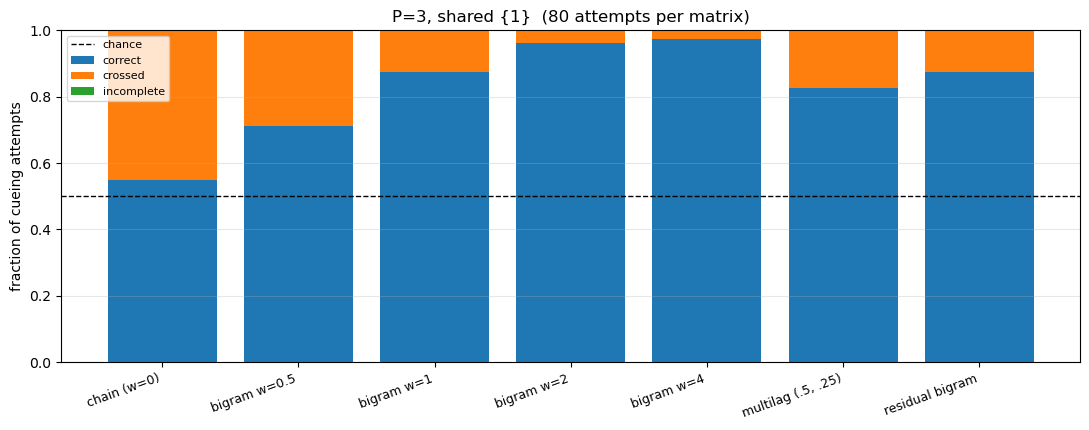

In [8]:
print("P = 3, shared {1}")
out_e1, _ = crossover_sweep(note_catalogue(3, shared_run=1), 3, (1,), duration=60.0)
plot_outcomes(out_e1, "P=3, shared {1}")
plt.tight_layout(); plt.show()

At $P=3$ the catalogue is more degenerate than it looks. With only three patterns
`boundary="self"` clamps $\Sigma^{(2)}$ and $\Sigma^{(3)}$ onto the same matrix, so the
multilag and residual rows collapse onto members of the bigram family. They separate at
$P=5$.

## Experiment 2 — $P=5$, one crossover at index 2

Two patterns of run-up before the branch, two more transitions after it. $A[1]$ is still
unshared and still sits directly before the crossover, so a `nhop` = 2 edge is still
decisive.

P = 5, shared {2}


chain (w=0)               correct=  59%  crossed=  41%  incomplete=   0%


bigram w=0.5              correct=  66%  crossed=  32%  incomplete=   1%


bigram w=1                correct=  75%  crossed=  25%  incomplete=   0%


bigram w=2                correct=  78%  crossed=  21%  incomplete=   1%


bigram w=4                correct=  76%  crossed=  22%  incomplete=   1%


multilag (.5, .25)        correct=  79%  crossed=  21%  incomplete=   0%


residual bigram           correct=  92%  crossed=   8%  incomplete=   0%


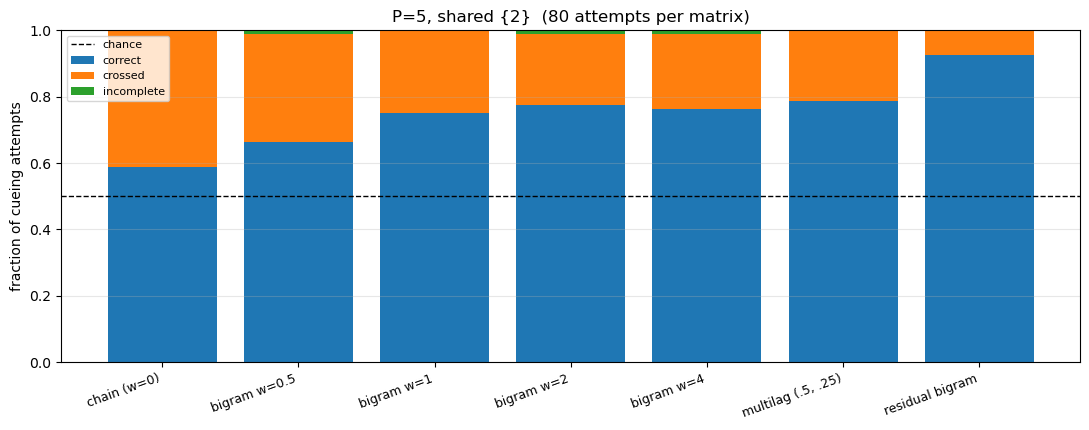

In [9]:
print("P = 5, shared {2}")
out_e2, first_e2 = crossover_sweep(note_catalogue(5, shared_run=1), 5, (2,), duration=100.0)
plot_outcomes(out_e2, "P=5, shared {2}")
plt.tight_layout(); plt.show()

## Experiment 3 — $P=5$, shared run of 3

Sixty percent of each sequence is shared. `residual bigram` is rebuilt with `shared_run=3`,
so its edge is `nhop` = 4. Every other matrix reaches at most 2.

P = 5, shared {1, 2, 3}


chain (w=0)               correct=  46%  crossed=  39%  incomplete=  15%


bigram w=0.5              correct=  50%  crossed=  48%  incomplete=   2%


bigram w=1                correct=  51%  crossed=  46%  incomplete=   2%


bigram w=2                correct=  52%  crossed=  48%  incomplete=   0%


bigram w=4                correct=  51%  crossed=  49%  incomplete=   0%


multilag (.5, .25)        correct=  52%  crossed=  45%  incomplete=   2%


residual bigram           correct=  79%  crossed=  21%  incomplete=   0%


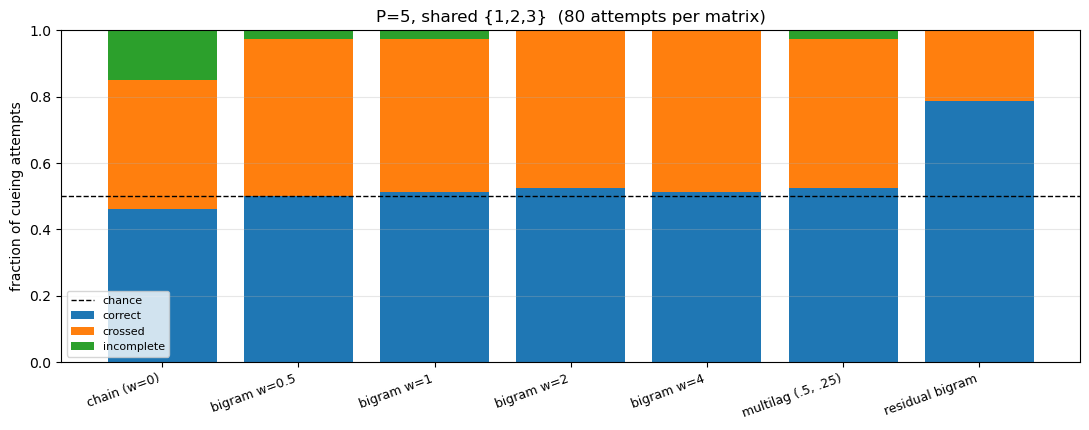

In [10]:
print("P = 5, shared {1, 2, 3}")
out_e3, first_e3 = crossover_sweep(note_catalogue(5, shared_run=3), 5, (1, 2, 3), duration=100.0)
plot_outcomes(out_e3, "P=5, shared {1,2,3}")
plt.tight_layout(); plt.show()

## The trend in $w$

Pulling the bigram entries out of the three experiments above. $w$ is the weight on the
lag-2 vote, so $w=0$ is the chain and larger $w$ means the older, unshared pattern speaks
more loudly.

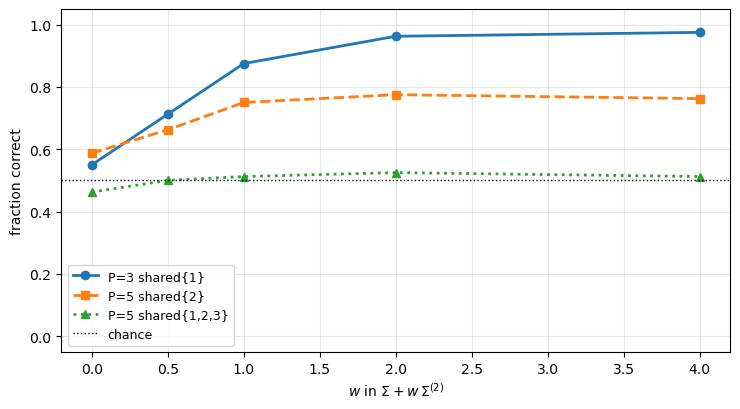

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
panels = [("P=3 shared{1}", out_e1, "-o"), ("P=5 shared{2}", out_e2, "--s"),
          ("P=5 shared{1,2,3}", out_e3, ":^")]
for tag, outcomes, style in panels:
    keys = ["chain (w=0)"] + [f"bigram w={w:g}" for w in W_VALUES[1:]]
    attempts = sum(outcomes[keys[0]].values())
    ax.plot(W_VALUES, [outcomes[k]["correct"] / attempts for k in keys], style, lw=2, label=tag)
ax.axhline(0.5, color="k", ls=":", lw=1, label="chance")
ax.set_xlabel(r"$w$ in $\Sigma + w\,\Sigma^{(2)}$")
ax.set_ylabel("fraction correct")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Scan 2 — how far back the edge has to reach

$\Sigma + \Sigma^{(\texttt{nhop})}$, varying `nhop`. For a shared run at indices
$\ell \ldots h$, the decisive edge runs from the last unshared pattern before the run to the
first unshared one after it:

$$\texttt{nhop}_{\min} = (h+1)-(\ell-1) = L+1, \qquad L = \text{run length}.$$

That is 2 for a single crossover and 4 for a run of three. Below the threshold the added edge
lands on a pattern that is itself shared, so it adds drive but no information about which
branch the trajectory came from.

The matrices are printed underneath. At $P=5$, `nhop=4` is the first one with a nonzero
$T[4,0]$, the $a_0 \rightarrow a_4$ edge. `boundary="self"` clamps rows past the end, so
`nhop=5` is the same matrix as `nhop=4`.

In [12]:
NHOPS = [2, 3, 4, 5]

reach_out = {}
for tag, shared, duration in [("shared {2}", (2,), 100.0), ("shared {1,2,3}", (1, 2, 3), 100.0)]:
    need = max(shared) + 1 - (min(shared) - 1)
    print(f"P = 5, {tag}   decisive edge at nhop = {need}")
    reach_out[tag] = crossover_sweep(
        {f"nhop={h}": lag_matrix(5, [1.0] + [0.0] * (h - 2) + [1.0]) for h in NHOPS},
        5, shared, duration)[0]
    print()

for h in NHOPS:
    print(f"Sigma^({h}) at P=5   T[4,0] = {ktr.shift_transition(5, nhop=h)[4, 0]:.0f}")
    print(ktr.shift_transition(5, nhop=h).astype(int), "\n")

P = 5, shared {2}   decisive edge at nhop = 2


nhop=2                    correct=  75%  crossed=  25%  incomplete=   0%


nhop=3                    correct=  92%  crossed=   8%  incomplete=   0%


nhop=4                    correct=  98%  crossed=   2%  incomplete=   0%


nhop=5                    correct=  98%  crossed=   2%  incomplete=   0%

P = 5, shared {1,2,3}   decisive edge at nhop = 4


nhop=2                    correct=  51%  crossed=  46%  incomplete=   2%


nhop=3                    correct=  51%  crossed=  49%  incomplete=   0%


nhop=4                    correct=  79%  crossed=  21%  incomplete=   0%


nhop=5                    correct=  79%  crossed=  21%  incomplete=   0%

Sigma^(2) at P=5   T[4,0] = 0
[[0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 1 1]] 

Sigma^(3) at P=5   T[4,0] = 0
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 0 0 0 0]
 [0 1 1 1 1]] 

Sigma^(4) at P=5   T[4,0] = 1
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 1]] 

Sigma^(5) at P=5   T[4,0] = 1
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [1 1 1 1 1]] 



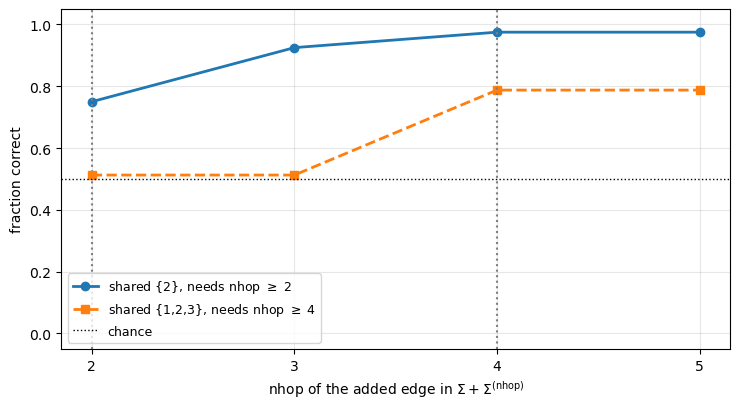

In [13]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for (tag, outcomes), style, need in zip(reach_out.items(), ("-o", "--s"), (2, 4)):
    attempts = sum(outcomes["nhop=2"].values())
    ax.plot(NHOPS, [outcomes[f"nhop={h}"]["correct"] / attempts for h in NHOPS],
            style, lw=2, label=f"{tag}, needs nhop $\\geq$ {need}")
    ax.axvline(need, color="tab:grey", ls=":", lw=1.5)
ax.axhline(0.5, color="k", ls=":", lw=1, label="chance")
ax.set_xlabel(r"nhop of the added edge in $\Sigma + \Sigma^{(\mathrm{nhop})}$")
ax.set_xticks(NHOPS)
ax.set_ylabel("fraction correct")
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Traces

Trial 0 of each $P=5$ geometry under the plain chain and under the matching
`residual bigram` matrix,
cued from both sequences. Read the tail of each panel: under the chain the two terminal
overlaps rise together out of the shared region, which is the ambiguity itself.

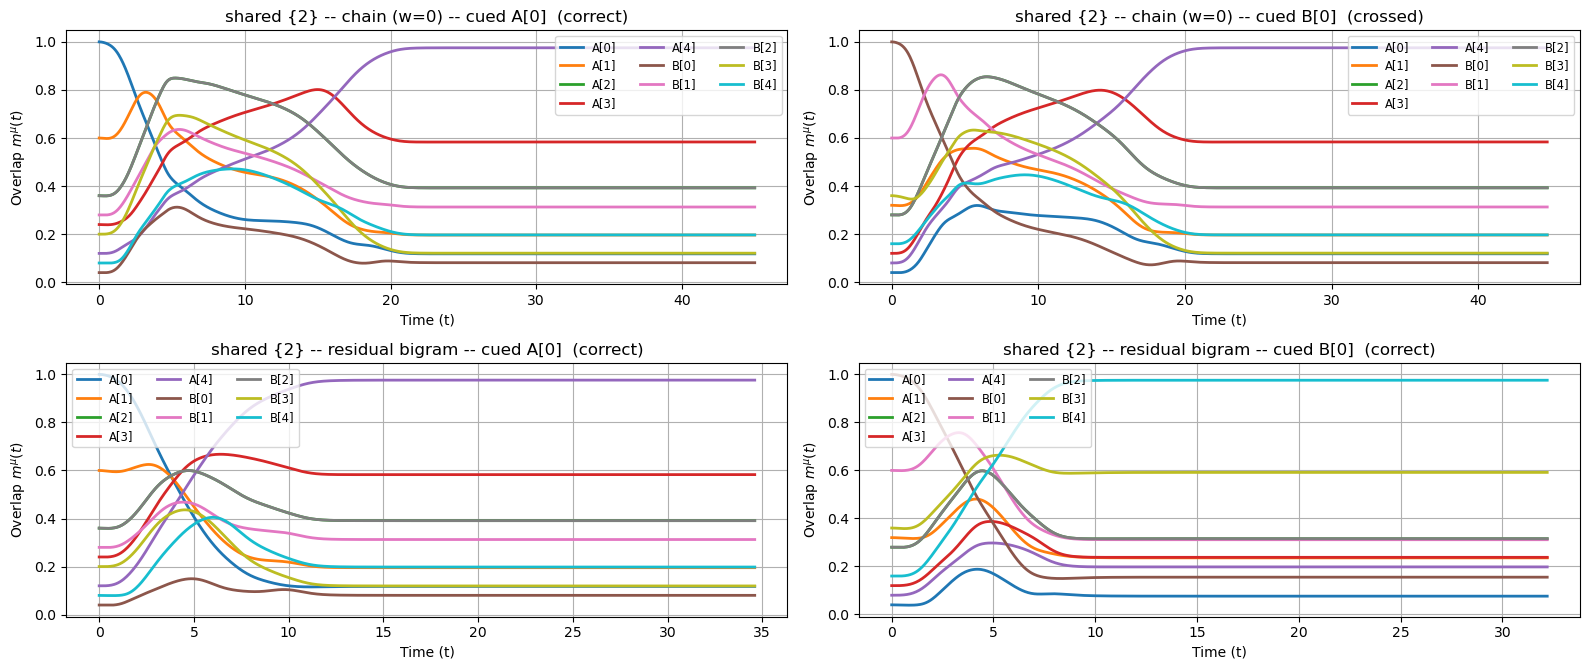

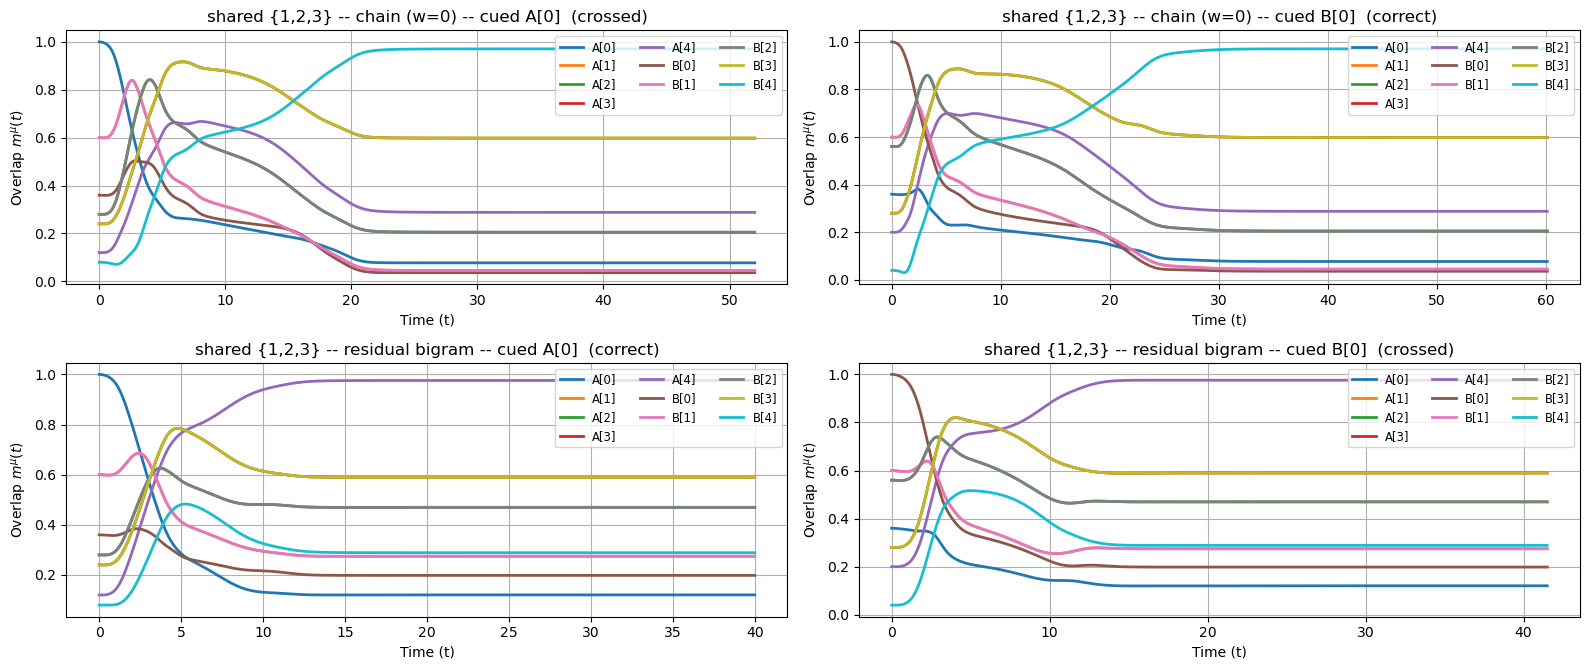

In [14]:
for first, tag in [(first_e2, "shared {2}"), (first_e3, "shared {1,2,3}")]:
    picked = ["chain (w=0)", "residual bigram"]
    fig, axes = plt.subplots(len(picked), 2, figsize=(16, 3.4 * len(picked)))
    for row, rule in enumerate(picked):
        net, multi, out = first[rule]
        for col, cued in enumerate(("A", "B")):
            net.plot(out[cued]["result"], multi, ax=axes[row, col],
                     title=f"{tag} -- {rule} -- cued {cued}[0]  ({out[cued]['outcome']})")
    plt.tight_layout(); plt.show()

---

# 4. 100 seeds at a randomized corruption rate

Every experiment so far used exactly `CONFIG["corruption_rate"]`, which tests the rules at
one operating point. Here the rate is **drawn once per seed** and then used for every
mutation in that trial's sequences. Each of the 100 trials is therefore an internally
consistent instance at its own difficulty, and the difficulty varies across trials.

This is harder than redrawing the rate at every mutation would be. A sequence generated
entirely at 0.28 has *every* consecutive pair 28% apart, where per-mutation draws would
average out within the sequence. So expect a higher `incomplete` fraction here than in
section 3.

`krm.corrupt_phase` turns a rate into a flip count with `int(rate * N)`, which truncates and
so lands below the requested rate on average. `sample_corruption_rate` rounds the count
stochastically instead, so its expectation is the requested rate, and returns a rate that
`corrupt_phase` truncates to exactly that count. `make_crossover_run` is used unchanged.

In [15]:
CORRUPTION_TARGET = CONFIG["corruption_rate"]   # 0.2
CORRUPTION_SPREAD = 0.08                        # per-seed rate ~ U[0.12, 0.28]
SEED_TRIALS       = 100

def sample_corruption_rate(target, spread, N, rng):
    """One corruption rate, stochastically rounded to a whole flip count.

    Returns (k + 0.5)/N so that corrupt_phase's int() truncation lands on exactly k, where
    k = floor(rN) + Bernoulli(frac(rN)) and so E[k] = rN."""
    rate = rng.uniform(target - spread, target + spread)
    exact = rate * N
    floor = np.floor(exact)
    flips = int(floor + (rng.random() < exact - floor))
    return (flips + 0.5) / N


def seed_sweep(catalogue, seq_len, shared_idx, duration, trials=SEED_TRIALS, seed=0):
    """`crossover_sweep` with one corruption rate drawn per trial instead of a fixed one.

    Every matrix is re-seeded to the same value, so all of them see the identical instances
    at the identical rates."""
    outcomes = {}
    for name, T in catalogue.items():
        net = ktr.TransitionNetwork(transition=T, N=N, seed=10, **CONFIG)
        rng = np.random.default_rng(seed)
        counter = Counter()
        for _ in range(trials):
            rate = sample_corruption_rate(CORRUPTION_TARGET, CORRUPTION_SPREAD, N, rng)
            origin_seed = int(rng.integers(SEED_POOL))
            mutation_seeds = rng.choice(SEED_POOL, size=12, replace=False).tolist()
            multi = make_crossover_run(N, rate, origin_seed, mutation_seeds, seq_len, shared_idx)
            for cued in ("A", "B"):
                result = net.simulate(multi, cue=multi[cued], cue_idx=0, T=duration)
                retrieved = net.decode_sequence_online(result, multi, margin=MARGIN)
                counter[classify_terminal(retrieved, multi, cued)] += 1
        outcomes[name] = counter
        attempts = sum(counter.values())
        print(f"{name:<25} correct={counter['correct'] / attempts:>5.0%}  "
              f"crossed={counter['crossed'] / attempts:>5.0%}  "
              f"incomplete={counter['incomplete'] / attempts:>5.0%}")
    return outcomes

In [16]:
print(f"P = 5, shared {{2}} -- {SEED_TRIALS} seeds")
seed_out_1 = seed_sweep(note_catalogue(5, shared_run=1), 5, (2,), duration=100.0)
print()
print(f"P = 5, shared {{1,2,3}} -- {SEED_TRIALS} seeds")
seed_out_3 = seed_sweep(note_catalogue(5, shared_run=3), 5, (1, 2, 3), duration=100.0)

P = 5, shared {2} -- 100 seeds


chain (w=0)               correct=  32%  crossed=  35%  incomplete=  34%


bigram w=0.5              correct=  55%  crossed=  28%  incomplete=  16%


bigram w=1                correct=  60%  crossed=  24%  incomplete=  16%


bigram w=2                correct=  62%  crossed=  22%  incomplete=  16%


...

bigram w=1                correct=  42%  crossed=  38%  incomplete=  20%


bigram w=2                correct=  44%  crossed=  38%  incomplete=  18%


bigram w=4                correct=  44%  crossed=  42%  incomplete=  14%


multilag (.5, .25)        correct=  40%  crossed=  38%  incomplete=  22%


residual bigram           correct=  60%  crossed=  24%  incomplete=  15%


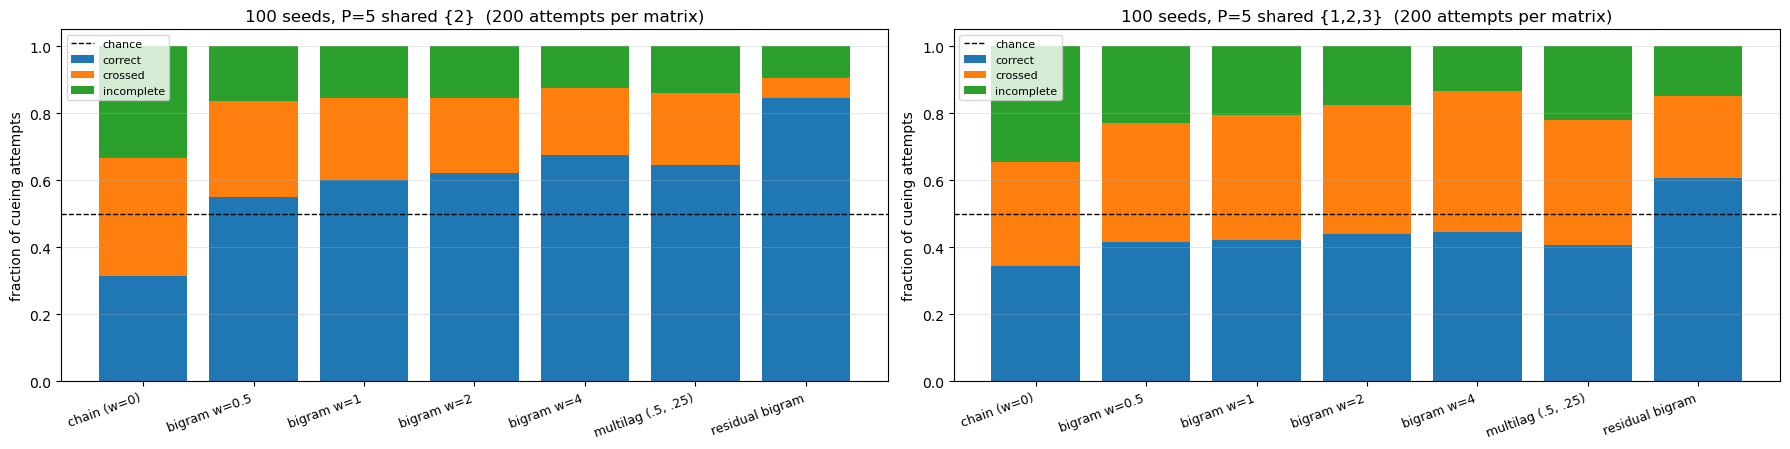

matrix                       shared {2}    shared {1,2,3}     (fraction correct)
------------------------------------------------------------
chain (w=0)                         32%               34%
bigram w=0.5                        55%               42%
bigram w=1                          60%               42%
bigram w=2                          62%               44%
bigram w=4                          68%               44%
multilag (.5, .25)                  64%               40%
residual bigram                     84%               60%


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4.6))
plot_outcomes(seed_out_1, f"{SEED_TRIALS} seeds, P=5 shared {{2}}", ax=axes[0])
plot_outcomes(seed_out_3, f"{SEED_TRIALS} seeds, P=5 shared {{1,2,3}}", ax=axes[1])
plt.tight_layout(); plt.show()

print(f"{'matrix':<25}{'shared {2}':>14}{'shared {1,2,3}':>18}     (fraction correct)")
print("-" * 60)
for name in seed_out_1:
    a1 = sum(seed_out_1[name].values()); a3 = sum(seed_out_3[name].values())
    print(f"{name:<25}{seed_out_1[name]['correct'] / a1:>14.0%}{seed_out_3[name]['correct'] / a3:>18.0%}")